# FE621 Final

Cian Gahan

Please note that for submission purposes I had to zip the notebook source and pdf into a temporary folder within src/ (there was only one file submission slot). The notebook code will not run in this location, it needs to be placed in a separate notebooks folder in the root with pyproject.toml/etc. This setup is available on my github

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from FE621.pricing.black_scholes import BlackScholes
from FE621.pricing.monte_carlo import GBMEuropean
from FE621.pricing.fdm import ExplicitFD, ImplicitFD
from FE621.pricing.tree import CRRBinomialTree

# Problem A: "The Customer's Quotes"

Market data (1980, mid-quotes). The current IBM stock price is $S_0 = \$100$. The continuously-compounded risk-free rate is r = 10% (3-month T-bill, 1980). IBM does not pay dividends for the
time interval considered. The five mid-quotes you receive are:

$$
\begin{array}{ccclc}
\textbf{Strike } K\text{ (\$)} & \textbf{Maturity } T\text{ (yrs)} & \textbf{Type} & \textbf{Mid-quote } C\text{ (\$)} \\
90  & 1/12 & Call & 13.79 \\
100 & 1/12 & Call & 7.30 \\
110 & 1/12 & Call & 3.04 \\
100 & 2/12 & Call & 10.84 \\
110 & 2/12 & Call & 6.09 \\
\end{array}
$$

In [2]:
s0 = 100
r = 0.1

midquotes = pd.DataFrame({
    "strike": [90, 100, 110, 100, 110],
    "maturity": [1/12, 1/12, 1/12, 2/12, 2/12],
    "type": ["Call"] * 5,
    "midquote": [13.79, 7.30, 3.04, 10.84, 6.09]
})
midquotes

,strike,maturity,type,midquote
0,90,0.083333,Call,13.79
1,100,0.083333,Call,7.30
2,110,0.083333,Call,3.04
3,100,0.166667,Call,10.84
4,110,0.166667,Call,6.09


(a) Black–Scholes pricer. See ```FE621/pricing/black_scholes.py``` for implementation.

(b) Bisection IV. See ```FE621/pricing/black_scholes.py``` for implementation. My algorithm's default tolerance is set to $10^{-6}$.

(c) Newton-Rhapson IV. See ```FE621/pricing/black_scholes.py``` for implementation.

Bisection/Newton-Rhapson results, including iteration counts and runtime comparison:

In [3]:
# bisection IV
midquotes[["biv", "biv_iter", "biv_runtime"]] = midquotes.apply(lambda row: BlackScholes.iv_call_bisection(
    s0, 
    row["strike"],
    row["maturity"],
    r,
    row["midquote"],
    log_iter=True,
    log_runtime=True,
), axis=1, result_type='expand')

# newton rhapson IV
midquotes[["nriv", "nriv_iter", "nriv_runtime"]] = midquotes.apply(lambda row: BlackScholes.iv_call_newton(
    s0,
    row["strike"],
    row["maturity"],
    r,
    row["midquote"],
    log_iter=True,
    log_runtime=True,
), axis=1, result_type='expand')

midquotes

,strike,maturity,type,midquote,biv,biv_iter,biv_runtime,nriv,nriv_iter,nriv_runtime
0,90,0.083333,Call,13.79,0.659818,22.0,0.000954,0.659819,4.0,0.000319
1,100,0.083333,Call,7.30,0.600395,22.0,0.000910,0.600395,3.0,0.000197
2,110,0.083333,Call,3.04,0.550290,22.0,0.001094,0.550290,4.0,0.000258
3,100,0.166667,Call,10.84,0.620274,22.0,0.000881,0.620274,3.0,0.000186
4,110,0.166667,Call,6.09,0.569801,22.0,0.000875,0.569801,4.0,0.000253


Based on the runtime and iteration counts, it seems clear that the Newton-Rhapson method is superior to the bisection method. Both methods converge to the same implied volatility value to 5-6 decimal places for all pricing scenarios, while the Newton Rhapson method takes about 0.16-0.22 times as many iterations and executes roughly 3-4X faster than the bisection method, so it is most efficient.

(d) Volatility Surface:

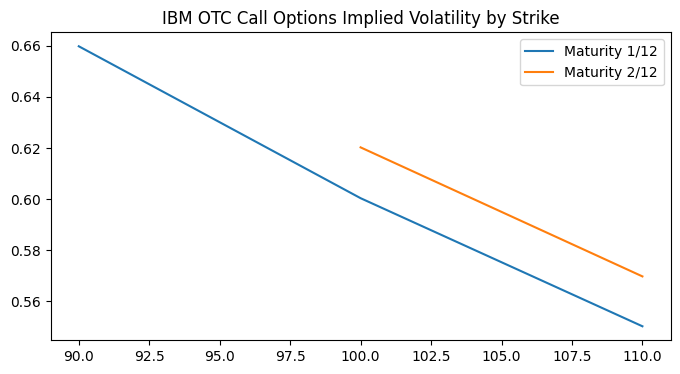

In [4]:
plt.figure(figsize=(8,4))
m1 = midquotes[midquotes["maturity"] == 1/12]
m2 = midquotes[midquotes["maturity"] == 2/12]
plt.plot(m1["strike"], m1["biv"], label="Maturity 1/12")
plt.plot(m2["strike"], m2["biv"], label="Maturity 2/12")
plt.title("IBM OTC Call Options Implied Volatility by Strike")
plt.legend()
plt.show()

(d-e) It appears that a higher strike price/lower option price is associated with a lower implied volatility with a roughly linear shape, holding all else constant. This implies that the Black-Scholes log-normal assumption is likely incorrect from the perspective of the competing trader; else the implied volatilities would all be close to one another. If I were a client I would be most likely to purchase one of the OTM call options (probably the January maturity) as the volatility is cheapest. Typically the volatility smile seen in practice makes OTM and ITM options have higher implied volatilities than ATM options, so the OTM calls seem cheaper than anticipated

# Problem B: The Four-Way Cross-Check

**Parameters:** Use $S_0 = 100$, K = 100, T = $\frac 1{12}$ (1 month), r = $10\%$, and $\sigma = 0.6$ for this part.

(a) Closed-form Black–Scholes. Compute and report $C_{BS}$.

(b) Plain Monte Carlo. Simulate the terminal stock price under risk-neutral GBM:

$$
S_T = S_0 exp((r - \frac12 \sigma^2)T \sigma \sqrt T Z), Z \sim \mathcal{N}(0, 1)
$$

Estimate $C_{MC} = e^{-rT}\mathbb{E}[(S_T - K)^+]$ as a function of the number of paths $M \in {10^4, 10^5, 10^6}$. For each M, report $\hat{C}$, the standard error, the 95% confidence interval, and the runtime. Does the BS price fall inside your CI? Plot the standard error against M on a log-log scale.

In [5]:
r = 0.1
sigma = 0.6

params = [
    {"s0": 100, "k": 100, "t": 1/12},
    {"s0": 100, "k": 110, "t": 1/12},
    {"s0": 110, "k": 100, "t": 2/12},
]

# black scholes
bscall = BlackScholes.call(params[0]["s0"], params[0]["k"], params[0]["t"], r, sigma)
print("Black Scholes Call Price:", bscall)

# monte carlo comparison
mc = pd.DataFrame(columns=["val", "se", "95low", "95high", "runtime", "abserr", "contains_bs"])
crosscheck = mc.drop(["95low", "95high", "contains_bs"], axis=1)
mc.index.name = "m"

gbm_mc = GBMEuropean(r, params[0]["s0"], params[0]["k"], params[0]["t"], sigma)

for m in [10000, 100000, 1000000]:
    val, se, runtime = gbm_mc.simulate(m, av=False, call=True)
    mc.loc[m] = val, se, val - 1.96 * se, val + 1.96 * se, runtime, val - bscall, abs(val - bscall) / 1.96 <= se

print("\nMonte Carlo Comparison:\n")
with pd.option_context('display.float_format', lambda x: '%.4f' % x):
    print(mc)

Black Scholes Call Price: 7.295487929876039

Monte Carlo Comparison:

           val     se  95low  95high  runtime  abserr  contains_bs
m                                                                 
10000   7.3301 0.1147 7.1053  7.5549   0.0008  0.0346         True
100000  7.3276 0.0365 7.2561  7.3992   0.0020  0.0321         True
1000000 7.3010 0.0115 7.2785  7.3235   0.0191  0.0056         True


The confidence intervals all contain the Black-Scholes price.

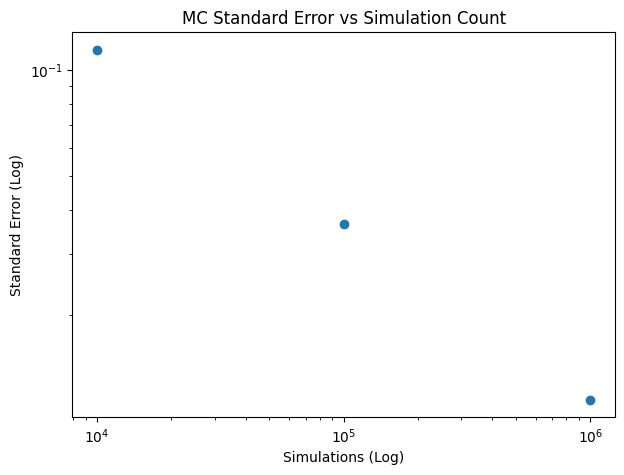

In [14]:
plt.figure(figsize=(7, 5))
plt.scatter(mc.index, mc["se"])
plt.xscale("log")
plt.xlabel("Simulations (Log)")
plt.yscale("log")
plt.ylabel("Standard Error (Log)")
plt.title("MC Standard Error vs Simulation Count")
plt.show()

In the log-log scale, increasing simulation count seems to consistently reduce the standard error. This makes sense, since standard error theoretically decreases with the square root of the simulation count, which is linear in log-log space.

(c) Explicit Finite Difference. Solve the BS PDE

$$
\delta_t V + \frac12 \sigma^2 S^2 \delta_{SS} V + r S \delta_S V - rV = 0
$$

on a log-price grid x = ln S using explicit time-stepping. Choose $\Delta t, \Delta x$ such that the stability condition is satisfied; state your choices. Truncate the grid at $S_{min} = S_0 e^{-3\sigma \sqrt T}$ and $S_{max} = S_0 e^{3\sigma \sqrt T}$ with the standard call boundary conditions. Report $C_{EFD}$.

Choosing $\Delta t, \Delta x$:

My function automatically chooses $\Delta x = \sigma * \sqrt {3 * \Delta t}$ to satisfy the stability condition. In order to keep the entire log price grid within $\log{S_0} \pm 3\sigma \sqrt T$, we must have:

$$
\begin{aligned}
n \Delta x < 3 \sigma \sqrt T \\
n \sigma * \sqrt {3 * \Delta t} < 3 \sigma \sqrt T \\
n \sqrt {\Delta t} < \sqrt {3T} \\
\sqrt n \sqrt {n \Delta t} < \sqrt {3T} \\
\sqrt {nT} < \sqrt {3T} \\
n < 3
\end{aligned}
$$

This doesn't make sense so I will assume I am meant to truncate all price calculations above or below this point by assuming the call is valued at its payoff value with no time impact. (thus the price shape in grid turns from a sideways triangle into a sideways triangle with the top and bottom removed). see ```FE621/pricing/fdm.py``` for implementation.

Given my selection of $\Delta x$ the result converges on the order of $\Delta t$. The given maturity is $T = \frac 1 {12}$ so I will choose N = 1000 to stay safe. This implies $\Delta t = \frac 1{12000}$ and $\Delta x \approx 0.009486$.

Results in the cross-validation table (params set 1)

(d) Implicit finite difference: Same problem with implicit time-stepping (solve a
tridiagonal system at each step). Report $C_{IFD}$.

Results in the cross-validation table (params set 1)

(e) Cross-Validation Table Place all four results (BS, MC, EFD, IFD) side by side
in one table at three parameter triples (use $\sigma = 0.60$ throughout this table):

(i) (S0 = 100, K = 100, T = 1/12) (ATM, base case)
(ii) (S0 = 100, K = 110, T = 1/12) (OTM)
(iii) (S0 = 110, K = 100, T = 2/12) (ITM, longer maturity)

Each row should show $\hat{C}$, SE (where applicable), runtime in seconds, and absolute error against
the BS benchmark. Conclude with two sentences arguing whether your “one-millisecond BS quote” is materially equivalent to Salomon’s overnight MC.

In [6]:
for p in range(len(params)):
    # black-scholes
    start = time.perf_counter()
    bscall = BlackScholes.call(params[p]["s0"], params[p]["k"], params[p]["t"], r, sigma)
    end = time.perf_counter()
    crosscheck.loc[f"BS params {p+1}"] = [bscall, np.nan, end - start, 0]

    # monte carlo
    start = time.perf_counter()
    gbm_mc = GBMEuropean(r, params[p]["s0"], params[p]["k"], params[p]["t"], sigma)
    mccall, se, runtime = gbm_mc.simulate(1000000, av=False, call=True)
    end = time.perf_counter()
    crosscheck.loc[f"MC params {p+1}"] = [mccall, se, end - start, abs(mccall - bscall)]
    
    # explicit fd
    start = time.perf_counter()
    efd = ExplicitFD(r, 0, sigma, params[p]["s0"], params[p]["t"], n=1000)
    efdcall = efd.price_option_truncated(params[p]["k"], call=True)
    end = time.perf_counter()
    crosscheck.loc[f"EFD params {p+1}"] = [efdcall, np.nan, end - start, abs(efdcall - bscall)]
    
    # implicit fd - chose the same n, nj = m, and dx as efd for comparability
    start = time.perf_counter()
    ifdcall = ImplicitFD.price_option(
        params[p]["s0"], params[p]["k"], r, 0, sigma, params[p]["t"], N=1000, Nj=int(3 * sigma * np.sqrt(params[p]["t"]) / 0.009486), dx=0.009486, 
        call=True, american=False
    )
    end = time.perf_counter()
    crosscheck.loc[f"IFD params {p+1}"] = [ifdcall, np.nan, end - start, abs(ifdcall - bscall)]

crosscheck

,val,se,runtime,abserr
BS params 1,7.295488,NaN,0.000270,0.000000
MC params 1,7.297961,0.011493,0.018879,0.002473
EFD params 1,7.293516,NaN,0.038186,0.001972
IFD params 1,7.292047,NaN,0.074750,0.003441
BS params 2,3.559345,NaN,0.000119,0.000000
MC params 2,3.558386,0.008258,0.017474,0.000959
EFD params 2,3.557888,NaN,0.037754,0.001457
IFD params 2,3.557153,NaN,0.075185,0.002192
BS params 3,17.017319,NaN,0.000129,0.000000
MC params 3,17.028660,0.021821,0.021486,0.011341


Based on the results of the cross-check, I would argue that the closed-form black scholes quote is materially equivalent to the overnight Monte Carlo simulation. From the chart, it is clear that all of the option values are very close to the black-scholes value, with absolute error well within 1 cent under all pricing scenarios, which should be sufficient precision.

## Problem C: "How Do We Actually Make Money?"

Setup: Same option as in B

(a) Analytical Greeks (5 pts). Compute the closed-form values of delta, gamma, theta, and vega for the ATM call, and report them in a single table.

In [7]:
s0 = 100
k = 100
t = 1/12
r = 0.1
sigma = 0.6

# Analytical Greeks
greeks = pd.DataFrame(
    {"value": [
        BlackScholes.delta_call(s0, k, t, r, sigma),
        BlackScholes.gamma(s0, k, t, r, sigma),
        BlackScholes.vega(s0, k, t, r, sigma),
        BlackScholes.theta_call(s0, k, t, r, sigma),
    ]},
    index=["delta", "gamma", "vega", "theta"]
)
greeks

,value
delta,0.553581
gamma,0.022825
vega,11.412443
theta,-45.891060


(b) The one-day delta-hedge P&L (15 pts). At t = 0 you sell one call at C0 = CBS and
immediately buy $\Delta_0 = \Delta_{BS}(S0)$ shares of stock. One trading day later $(\Delta_t = 1/252)$, the stock
has moved to

$$
S_{\Delta t} = S_0 exp((r - \frac12 \sigma^2)\Delta t + \sigma \sqrt{\Delta t} Z)
$$

One-day P&L (bank funding included) is 

$$
P\&L(Z) = -[C(S_{\Delta t}, T - \Delta t) - C_0] + \Delta_0 * (S_{\Delta t} - S_0) - r(\Delta_0S_0 - C_0)\Delta t
$$

Generate M = 10,000 samples of Z, compute the P&L distribution, plot a histogram, and
report:
• mean, median, and standard deviation of P&L;
• 5% and 95% empirical quantiles;
• a 95% confidence interval for the mean P&L (use $\bar{X} \pm 1.96 s/\sqrt M$ , where s is the sample
standard deviation).

In [8]:
m=10000
z = np.random.standard_normal(m)
dt = 1/252

c0 = BlackScholes.call(s0, k, t, r, sigma)
d0 = BlackScholes.delta_call(s0, k, t, r, sigma)

s1 = s0 * np.exp((r - 0.5 * sigma ** 2) * dt + sigma * np.sqrt(dt) * z)
c1 = BlackScholes.call(s1, k, t - dt, r, sigma)

pnl = c0 - c1 + d0 * (s1 - s0) - r * (d0 * s0 - c0) * dt

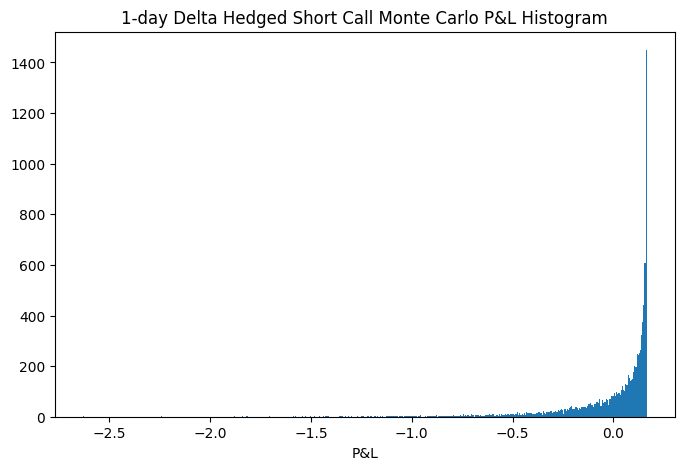

In [9]:
plt.figure(figsize=(8, 5))
plt.hist(pnl, bins=500)
plt.xlabel("P&L")
plt.title("1-day Delta Hedged Short Call Monte Carlo P&L Histogram")
plt.show()

In [11]:
print("Mean P&L:", '%.6f' % pnl.mean())
print("Median P&L:", '%.6f' % np.quantile(pnl, 0.5))
print("Stdev of P&L:", '%.6f' % pnl.std())
print("95% CI P&L:", '%.6f' % (pnl.mean() - 1.96 * pnl.std() / np.sqrt(m)), "to", '%.6f' % (pnl.mean() + 1.96 * pnl.std() / np.sqrt(m)))

Mean P&L: -0.001672
Median P&L: 0.089329
Stdev of P&L: 0.234042
95% CI P&L: -0.006260 to 0.002915


Is the hedge “P&L-neutral” on average? Where does the residual
variance come from — which Greek? Suppose tomorrow’s realized volatility turns out to exceed
the implied $\sigma = 0.60$ used to price the option: who pockets the difference, the long-$\Gamma$ holder of
the call, or the short-$\Gamma$ writer (you) — and why? In real life, how often must you re-hedge to
keep this risk small — daily, hourly, by-the-tick?

I would say that the hedge is roughly PnL neutral on average. The 95% confidence interval for PnL includes 0, so the PnL does not statistically significantly differ from 0 based on the simulation results. I believe the residual variance comes primarily from gamma, since the volatility/interest rate is not changing and the time does not change by as much as the price. As the delta changes due to gamma from changes in the stock value, the hedge loses its efficiency as the delta of the call and stock position decouple. If tomorrow's realized volatility exceeds 0.6, the long holder of the call benefits as their entry into the postion was underpriced (higher implied vol increases the value of the position, so they effectively bought the option at a discount). In real life, the necessary hedging frequency likely depends on the volatility of the stock and moneyness of the option (hedging OTM or ITM options with lower gamma can probably be done at a lower frequency than ATM options, for example), but I would imagine somewhere between hourly and daily is most practical. Hedging at a tick level is necessary to eliminate the risk entirely from a theoretical standpoint.

# Problem D: The Moat: American Options

Parameters. S0 = 100, K = 100, T = 2/12 (2 months), r = 10%, $\sigma = 0.60$.

(a) Build the CRR binomial tree. Implement an additive (or equivalently multiplicative — state your choice) binomial tree pricer that handles four cases: European/American,
call/put. Use the recombining tree with $u = e^{\sigma \sqrt{\Delta t}}$, d = 1/u, and risk-neutral probability
$\frac{e^{r\Delta t} - d}{u-d}$.

I will use an additive tree in log-price scale. See ```FE621/pricing/tree.py``` for implementation.

(b) The American put. Price the American put $P_{Am}$ at K = 100, T = 2/12, with
N = 500 steps. Report:

• the European put price $P_{Eu}$ from the same tree,

• the American put price $P_{Am}$,

• the early-exercise premium $P_{Am} - P_{Eu}$

In [12]:
s0 = 100
k = 100
t = 2/12
r = 0.1
sigma = 0.6

# see FE621/pricing/tree.py for full binomial tree implementation
crr_tree = CRRBinomialTree(r, sigma, s0, t, 500)
put_euro = crr_tree.price_option(k, call=False, american=False)
put_am = crr_tree.price_option(k, call=False, american=True)
print("European Put Price:", put_euro)
print("American Put Price:", put_am)
print("Early Exercise Premium:", put_am - put_euro)

European Put Price: 8.858103774609736
American Put Price: 8.998166708454237
Early Exercise Premium: 0.14006293384450075


(c) The moat reflection. One paragraph: why does the binomial tree handle American options naturally, while Monte Carlo (in 1980) does not?

The binomial tree handles American options naturally because of its ability to easily look ahead to the result of several future paths at once. The recombining tree structure combines all possible paths (within a certain granularity based on dx, dt, etc) and evaluates them at the same time from the end to start of the time period. This means that American options can be integrated since the current stock price and future holding value of the option are viewable at the same time without looking ahead to the results of any given path, so early exercise conditions are easily identified. Monte Carlo simulations, on the other hand, are not naturally compatible with American options as they only view one path at a time, so it is difficult to evaluate whether early exercise at any given point is optimal without looking ahead to future values of the stock on the same path. 

# Final Reflection

In a final paragraph (5–10 sentences), reflect on the following:

• If you could only teach a 1980 trading desk one technique from this exam — the one you trust
most, and that anchors the correctness of the others — which would you pick, and why?

The most helpful technique I've found throughout this course thus far has been the tree-based pricing methods. They have been consistently useful in pricing the widest variety of exotic and early-exercise derivatives. Their ability to handle early exercise derivatives would have provided a significant innovation to a 1980s trading desk. The Monte Carlo simulations at the time could price most derivatives from the course given enough time to run the simulation, however, they could not price early exercise derivatives. Given the improvement in overall efficiency and ability to price a novel category of derivatives, I think the tree pricing models (binomial and trinomial trees) would be what I would teach.

• Now flip the time-travel: in 2026, name one technique you have studied this semester (in
FE621 or elsewhere) that you believe most working trading desks today do not yet routinely
use — but probably will, in the next decade. Briefly explain why this technique would give a
desk an edge today, in the same way the binomial tree gave your company (Morgan Stanley)
an edge in 1980.

My confidence in this answer is relatively low given that I have not worked on a trading desk. However, an impression I've gotten is that many trading desks tend to stick to simpler models (eg. Black-Scholes) for understanding the net risks of a desk's book. The GBM model ignores two of the key stylized facts of financial markets: fat tailed return distributions and clustered volatility. Because of this a desk which uses GBM to measure their net risks is not exactly measuring those risks given the incorrect model assumption. Using that calculated delta value to hedge the book may not hold up in practice, especially near maturity. Using a more complex Monte-Carlo based model with an underlying process that incorporates these risks and with variance reduction techniques to increase computational efficiency could allow the desk to more accurately price their derivatives and measure risk (potentially using a finite difference method to estimate the various derivatives).